# 🧠 EEG Motor Action Classification
## Notebook 1 — Dataset Exploration & Visualisation

---

**Dataset** : MILimbEEG (Mendeley, v2)  
**Task**    : 8-class motor action recognition (cross-subject)  
**Device**  : OpenBCI Cyton + Daisy — 16 channels, 125 Hz, bandpass 5–50 Hz  

### Class Labels

| ID | Label | Description |
|----|-------|-------------|
| 1  | BEO   | Baseline with Eyes Open |
| 2  | CLH   | Closing Left Hand |
| 3  | CRH   | Closing Right Hand |
| 4  | DLH   | Dorsal Flexion of Left Foot |
| 5  | PLF   | Plantar Flexion of Left Foot |
| 6  | DRF   | Dorsal Flexion of Right Foot |
| 7  | PRF   | Plantar Flexion of Right Foot |
| 8  | Rest  | Rest / No Action |

### Contents
1. Dataset statistics & class balance  
2. Raw signal visualisation (MNE)  
3. Power Spectral Density per class  
4. Event-Related Potentials  
5. Topographic power maps  
6. Preprocessing pipeline demonstration  
7. Cross-subject split summary  

---
## 0. Setup

In [1]:
import sys
from pathlib import Path

# Add project root to path
ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import mne

from config import (
    DATA_DIR, SFREQ, CH_NAMES, CLASS_NAMES, LABEL_MAP,
    N_CLASSES, TRAIN_SUBJECTS, VAL_SUBJECTS, TEST_SUBJECTS,
)
from src.data.loader import (
    load_dataset, compute_class_weights, get_dataset_summary, parse_filename
)
from src.data.preprocessing import (
    preprocess, to_mne_epochs, bandpass_filter, common_average_reference, zscore_normalize
)
from src.utils.visualization import (
    plot_raw_trial, plot_channel_psd, plot_erp,
    plot_topomap_class, plot_training_history,
)

mne.set_log_level('WARNING')
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

print('✅ All imports successful')
print(f'   MNE version  : {mne.__version__}')
print(f'   Dataset root : {DATA_DIR}')

/home/kalex/.local/lib/python3.11/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


✅ All imports successful
   MNE version  : 1.11.0
   Dataset root : /home/kalex/projects/ITMO/Diploma/datasets/MILimbEEG/MILimbEEG


---
## 1. Dataset Statistics

In [2]:
# Dataset summary table
summary = get_dataset_summary(DATA_DIR)

print(f'Total subjects : {len(summary)}')
print(f'Motor files    : {summary.values.sum()} trials')
print(f'\nTrials per label:')

label_totals = summary.sum()
for col, count in label_totals.items():
    label_num = int(col.replace('M', ''))
    name = LABEL_MAP.get(label_num, '?')
    print(f'  {col} ({name:4s}) : {int(count):5d}  ({100*count/label_totals.sum():.1f}%)')

print(f'\nTotal         : {int(label_totals.sum())}')

Total subjects : 60
Motor files    : 1860 trials

Trials per label:
  M1 (BEO ) :    60  (3.2%)
  M2 (CLH ) :   300  (16.1%)
  M3 (CRH ) :   300  (16.1%)
  M4 (DLH ) :   300  (16.1%)
  M5 (PLF ) :   300  (16.1%)
  M6 (DRF ) :   300  (16.1%)
  M7 (PRF ) :   300  (16.1%)

Total         : 1860


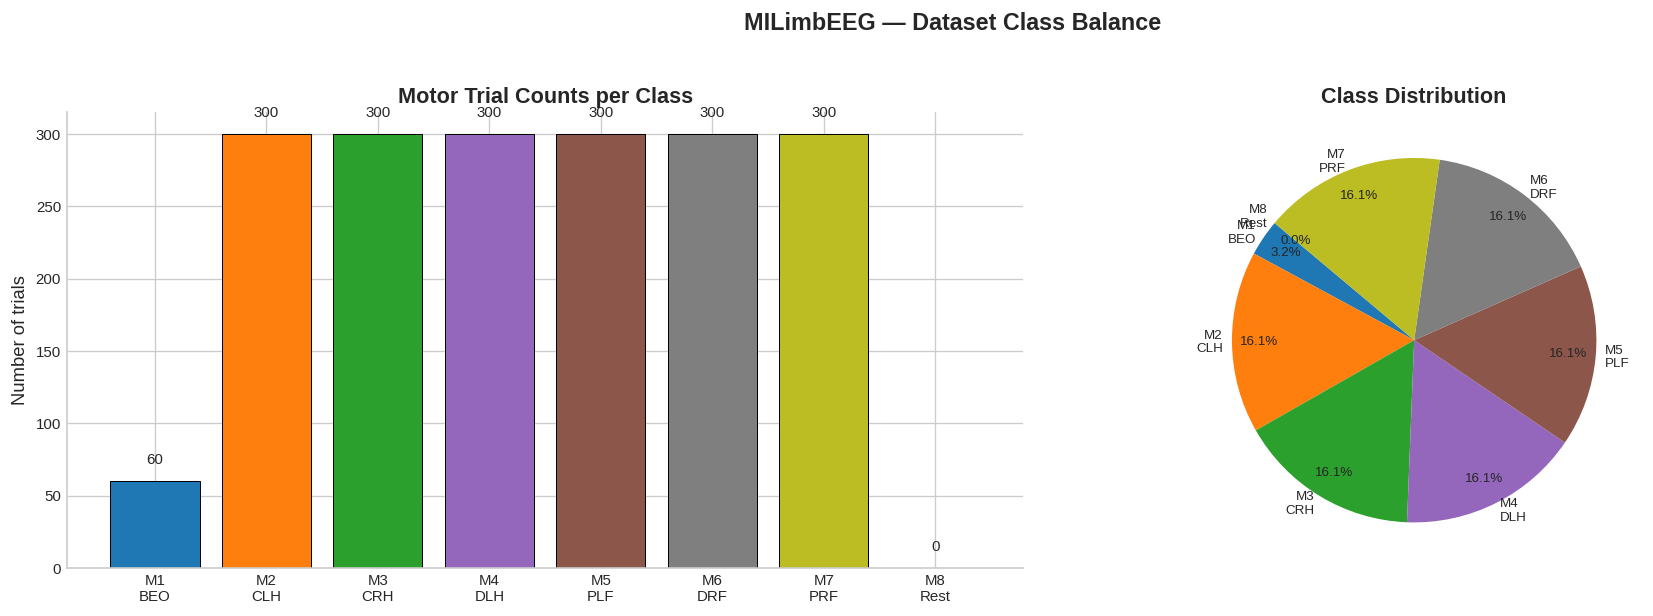

⚠️  Note: Heavy class imbalance — Rest (M8) has 1861 trials vs 60 for BEO (M1)
   → Will use class-weight balancing during training


In [3]:
# Class distribution bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Left: absolute counts ---
labels_plot  = [f'M{k}\n{v}' for k, v in LABEL_MAP.items()]
counts       = [int(label_totals.get(f'M{k}', 0)) for k in LABEL_MAP]
colors       = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))

bars = axes[0].bar(labels_plot, counts, color=colors, edgecolor='k', linewidth=0.6)
for bar, cnt in zip(bars, counts):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 str(cnt), ha='center', va='bottom', fontsize=9)
axes[0].set_title('Motor Trial Counts per Class', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of trials')
axes[0].spines[['top','right']].set_visible(False)

# --- Right: pie chart ---
axes[1].pie(
    counts, labels=labels_plot, colors=colors,
    autopct='%1.1f%%', startangle=140,
    pctdistance=0.85, labeldistance=1.05,
    textprops={'fontsize': 8},
)
axes[1].set_title('Class Distribution', fontsize=13, fontweight='bold')

plt.suptitle('MILimbEEG — Dataset Class Balance', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../results/01_class_balance.png', bbox_inches='tight', dpi=150)
plt.show()
print('⚠️  Note: Heavy class imbalance — Rest (M8) has 1861 trials vs 60 for BEO (M1)')
print('   → Will use class-weight balancing during training')

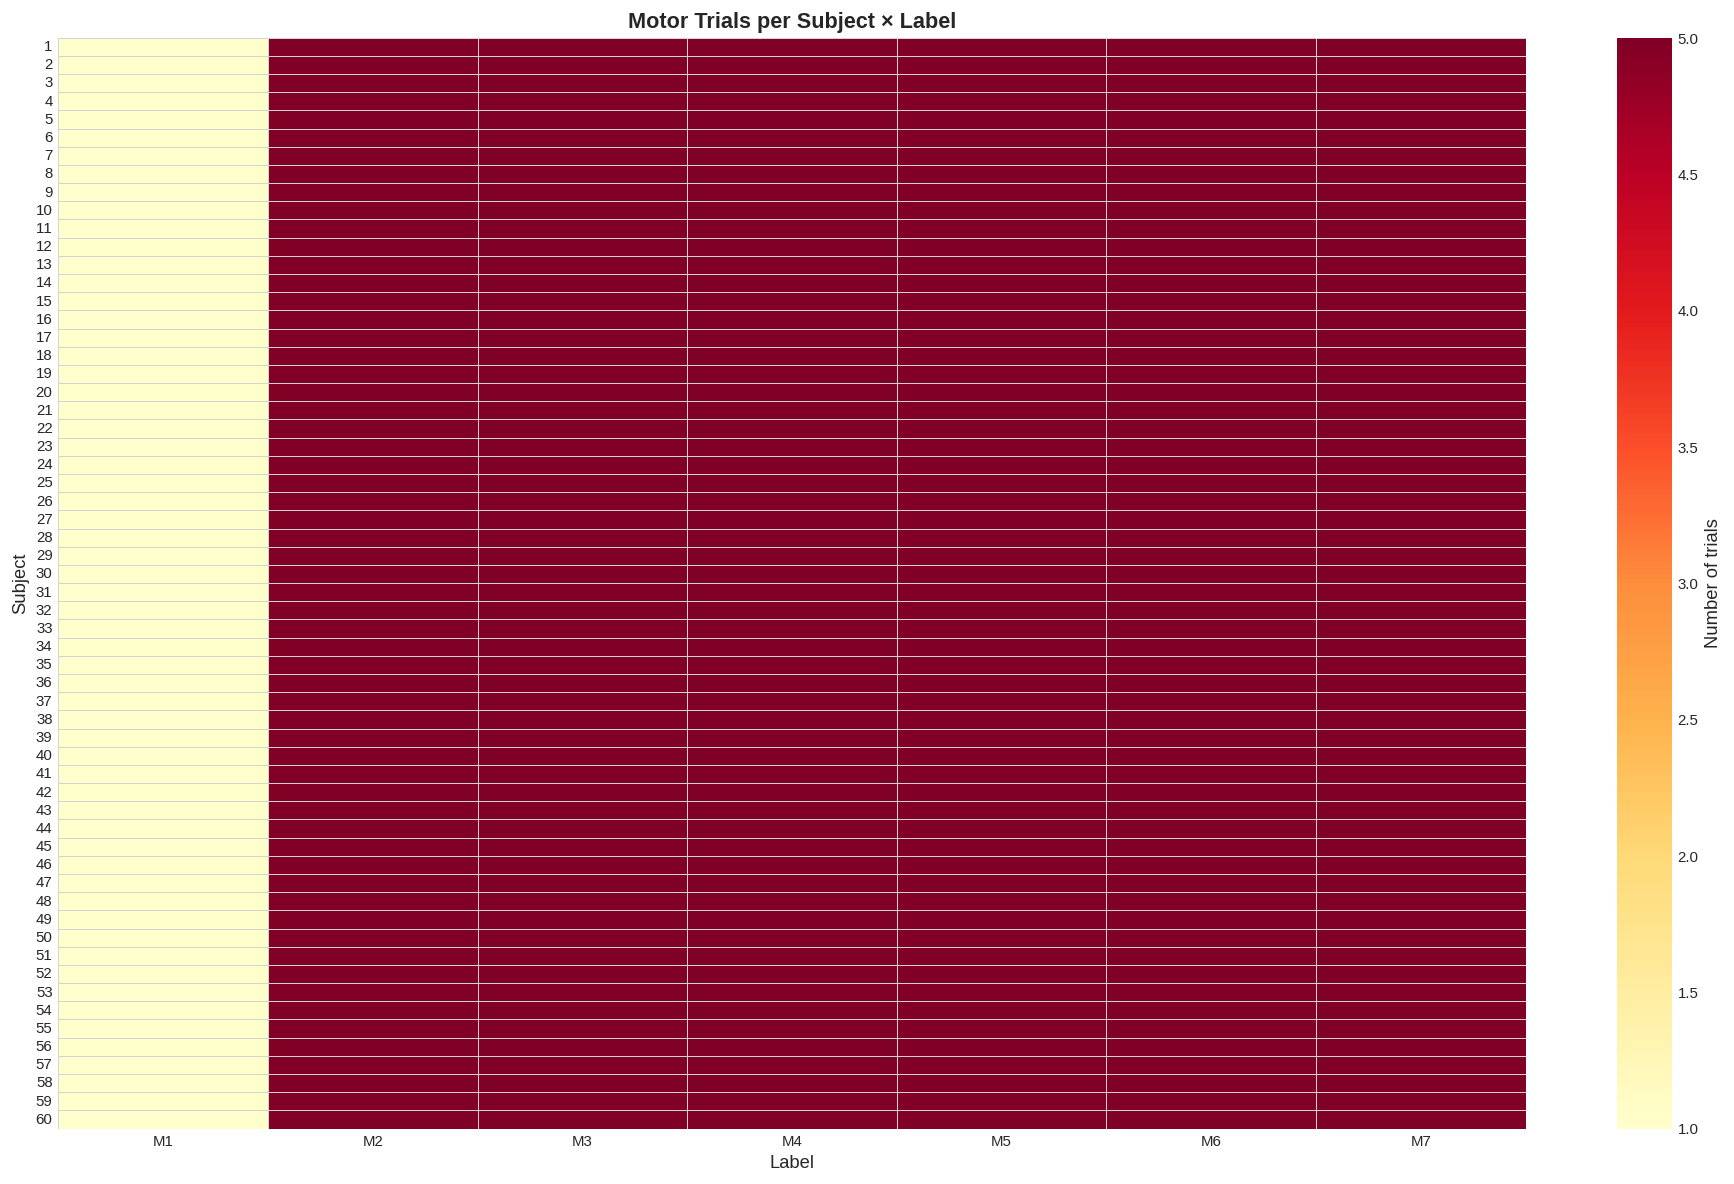

In [4]:
# Trials per subject heatmap
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    summary,
    ax=ax, cmap='YlOrRd', annot=False,
    linewidths=0.3, linecolor='lightgrey',
    cbar_kws={'label': 'Number of trials'},
)
ax.set_xlabel('Label', fontsize=11)
ax.set_ylabel('Subject', fontsize=11)
ax.set_title('Motor Trials per Subject × Label', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/01_subject_label_heatmap.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 2. Cross-Subject Split

In [5]:
print('Cross-Subject Split Strategy')
print('=' * 50)
print(f'  Train : subjects {TRAIN_SUBJECTS[0]}–{TRAIN_SUBJECTS[-1]}  ({len(TRAIN_SUBJECTS)} subjects, ~80%)')
print(f'  Val   : subjects {VAL_SUBJECTS[0]}–{VAL_SUBJECTS[-1]}    ({len(VAL_SUBJECTS)} subjects, ~10%)')
print(f'  Test  : subjects {TEST_SUBJECTS[0]}–{TEST_SUBJECTS[-1]}    ({len(TEST_SUBJECTS)} subjects, ~10%)')
print()
print('Rationale: No data from test subjects is seen during training.')
print('This evaluates generalisation to UNSEEN individuals — the clinically')
print('relevant scenario for a real BCI system.')

Cross-Subject Split Strategy
  Train : subjects 1–48  (48 subjects, ~80%)
  Val   : subjects 49–54    (6 subjects, ~10%)
  Test  : subjects 55–60    (6 subjects, ~10%)

Rationale: No data from test subjects is seen during training.
This evaluates generalisation to UNSEEN individuals — the clinically
relevant scenario for a real BCI system.


---
## 3. Load a Small Subset for Exploration

In [6]:
# Load first 10 subjects for fast EDA
X_eda, y_eda, meta_eda = load_dataset(
    subjects=list(range(1, 11)),
    normalize=False,   # keep raw µV values for MNE
    verbose=True,
)

print(f'\nLoaded: X={X_eda.shape}, y={y_eda.shape}')
print(f'Trial duration : {X_eda.shape[2] / SFREQ:.1f} s  ({X_eda.shape[2]} samples @ {SFREQ} Hz)')
print(f'Channels       : {X_eda.shape[1]} ({CH_NAMES})')

Loading trials: 100%|██████████| 310/310 [00:00<00:00, 743.36it/s]


Loaded: X=(310, 16, 500), y=(310,)
Trial duration : 4.0 s  (500 samples @ 125 Hz)
Channels       : 16 (['FC5', 'F3', 'Fz', 'F4', 'FC6', 'FC3', 'FC4', 'Cz', 'T7', 'CP5', 'C3', 'CP3', 'CP4', 'C4', 'CP6', 'T8'])


---
## 4. Raw Signal Visualisation

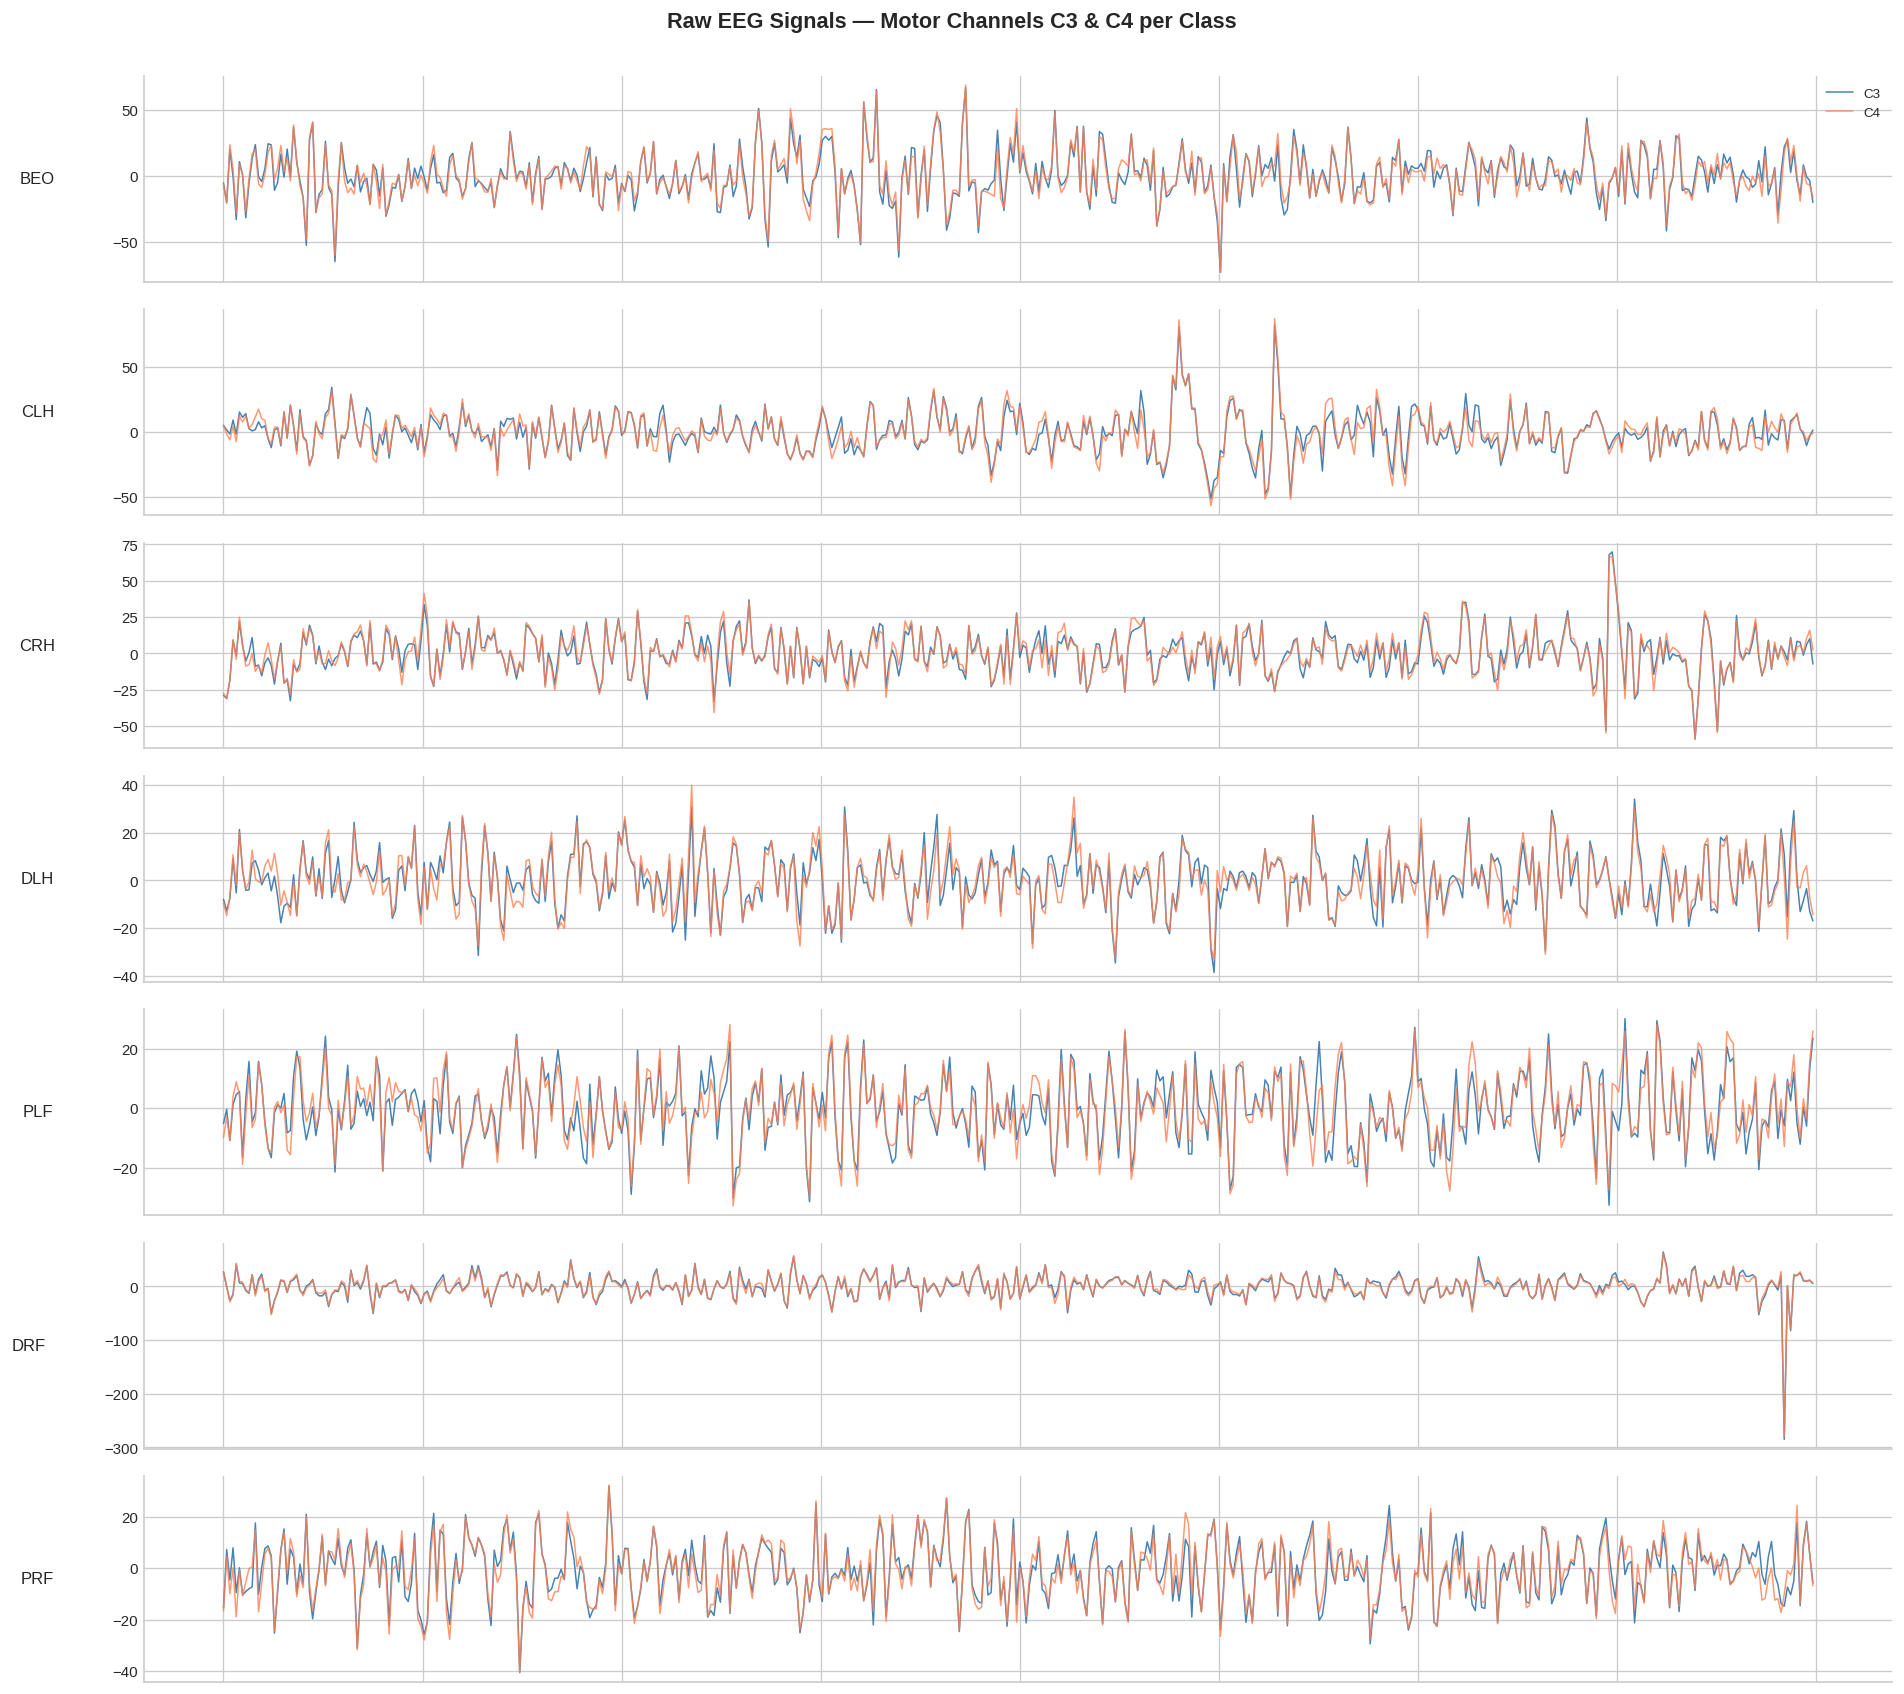

In [7]:
# Plot one trial per class (2 columns x 4 rows)
fig, axes = plt.subplots(N_CLASSES, 1, figsize=(16, N_CLASSES * 2), sharex=True)
times = np.arange(X_eda.shape[2]) / SFREQ

for cls_idx, ax in enumerate(axes):
    mask = y_eda == cls_idx
    if mask.sum() == 0:
        ax.set_visible(False)
        continue
    trial = X_eda[np.where(mask)[0][0], :, :]   # first trial of this class
    # Plot C3 (ch 10) and C4 (ch 13) — primary motor channels
    ax.plot(times, trial[10], label='C3',  color='steelblue', linewidth=0.9)
    ax.plot(times, trial[13], label='C4',  color='coral',     linewidth=0.9, alpha=0.8)
    ax.set_ylabel(CLASS_NAMES[cls_idx], fontsize=10, rotation=0, labelpad=45, va='center')
    ax.spines[['top','right']].set_visible(False)
    if cls_idx == 0:
        ax.legend(loc='upper right', fontsize=8)

axes[-1].set_xlabel('Time (s)', fontsize=11)
fig.suptitle('Raw EEG Signals — Motor Channels C3 & C4 per Class',
             fontsize=13, fontweight='bold', y=1.002)
plt.tight_layout()
plt.savefig('../results/01_raw_signals_per_class.png', bbox_inches='tight', dpi=150)
plt.show()

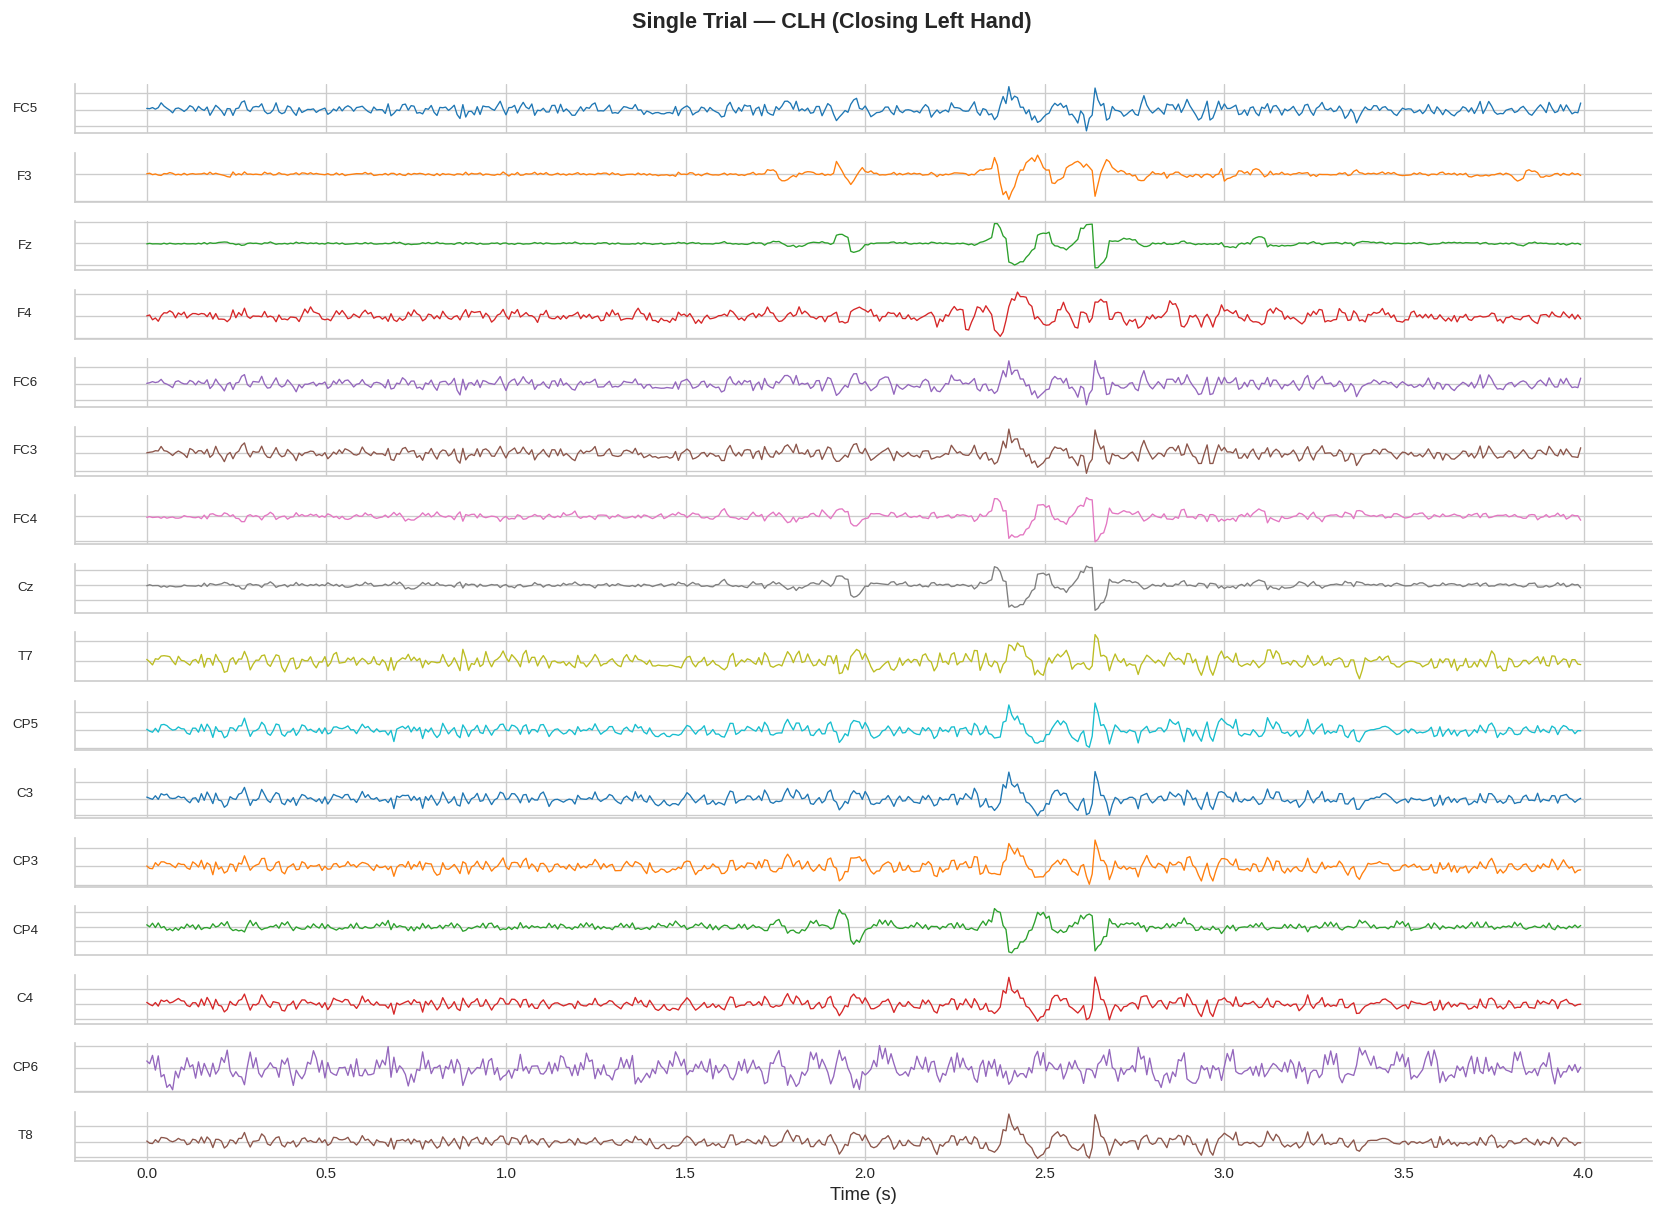

In [8]:
# Detailed single-trial all-channels plot
idx_clh = np.where(y_eda == 1)[0][0]   # first CLH trial
fig = plot_raw_trial(X_eda[idx_clh], label=2, title='Single Trial — CLH (Closing Left Hand)')
plt.savefig('../results/01_single_trial_all_channels.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 5. MNE EpochsArray & Brain Maps

In [9]:
# Wrap in MNE EpochsArray for proper EEG tooling
epochs = to_mne_epochs(X_eda * 1e-6, y_eda)  # MNE expects Volts, data is µV

print(epochs)
print('\nInfo:')
print(f'  Sampling rate : {epochs.info["sfreq"]} Hz')
print(f'  Channels      : {epochs.ch_names}')
print(f'  N epochs      : {len(epochs)}')

ValueError: No matching events found for Rest (event id 8)

In [ ]:
# Montage — map channels to 3D head positions for topoplots
montage = mne.channels.make_standard_montage('standard_1020')
epochs.set_montage(montage, on_missing='ignore')

# Plot the electrode positions
fig = epochs.plot_sensors(show_names=True, kind='topomap')
plt.suptitle('OpenBCI Electrode Positions (10-10 system)', fontsize=12, fontweight='bold')
plt.savefig('../results/01_electrode_positions.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Power Spectral Density — all classes on C3
fig = plot_channel_psd(X_eda, y_eda, channel=10, sfreq=SFREQ)
plt.savefig('../results/01_psd_per_class_C3.png', bbox_inches='tight', dpi=150)
plt.show()

print('\n📊 Key spectral features:')
print('  μ band  (8-13 Hz) : Event-Related Desynchronisation (ERD) during movement')
print('  β band (13-30 Hz) : Post-movement beta rebound (PMBR) after movement onset')

In [ ]:
# ERP plot — motor channels C3, Cz, C4
fig = plot_erp(X_eda, y_eda, channels=[10, 7, 13])
plt.savefig('../results/01_erp_motor_channels.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Topographic band-power maps
fig = plot_topomap_class(X_eda, y_eda, band=(8, 13))
plt.savefig('../results/01_topomap_mu_band.png', bbox_inches='tight', dpi=150)
plt.show()

print('\nμ-band (8–13 Hz) power topomaps per class.')
print('Hand classes (CLH/CRH) show contralateral ERD in C3/C4.')
print('Foot classes (DLH/PLF/DRF/PRF) show Cz ERD.')

---
## 6. Preprocessing Pipeline Demonstration

In [ ]:
# Show effect of each preprocessing step on one trial
trial_raw = X_eda[0, :, :]                          # (16, 500) — raw µV
trial_filt = bandpass_filter(X_eda[:1], l_freq=1.0, h_freq=49.0)[0]  # filtered
trial_car  = common_average_reference(trial_filt[np.newaxis])[0]     # + CAR
trial_norm = zscore_normalize(trial_car[np.newaxis])[0]              # + z-score

ch_idx = 10   # C3
times  = np.arange(500) / SFREQ

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
steps = [
    (trial_raw,  'Raw Signal (µV)',                  'tomato'),
    (trial_filt, 'After Band-Pass [1–49 Hz]',        'steelblue'),
    (trial_car,  'After CAR (Common Average Ref.)',  'darkorange'),
    (trial_norm, 'After Z-Score Normalisation',      'seagreen'),
]

for ax, (data, title, color) in zip(axes, steps):
    ax.plot(times, data[ch_idx], color=color, linewidth=0.9)
    ax.set_ylabel(title, fontsize=9)
    ax.spines[['top','right']].set_visible(False)

axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'Preprocessing Pipeline — Channel C3 (Subject 1, CLH)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/01_preprocessing_steps.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# Signal statistics before/after preprocessing
stats_df = pd.DataFrame({
    'Step'  : ['Raw', 'Filtered', 'CAR', 'Z-Score'],
    'Mean'  : [t[ch_idx].mean() for t in [trial_raw, trial_filt, trial_car, trial_norm]],
    'Std'   : [t[ch_idx].std()  for t in [trial_raw, trial_filt, trial_car, trial_norm]],
    'Min'   : [t[ch_idx].min()  for t in [trial_raw, trial_filt, trial_car, trial_norm]],
    'Max'   : [t[ch_idx].max()  for t in [trial_raw, trial_filt, trial_car, trial_norm]],
}).set_index('Step')

print('Signal Statistics at Each Preprocessing Step (Channel C3):')
print(stats_df.round(4).to_string())

---
## 7. Data Augmentation Preview

In [ ]:
from src.data.preprocessing import augment as augment_fn

X_proc = preprocess(X_eda[:10])
X_aug, _ = augment_fn(X_proc, y_eda[:10], noise_std=0.05)

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
t = np.arange(500) / SFREQ

axes[0].plot(t, X_proc[0, 10], color='steelblue', linewidth=0.9, label='Original')
axes[0].set_title('Original (preprocessed)')
axes[0].legend(); axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(t, X_aug[0, 10],  color='coral', linewidth=0.9, label='Augmented')
axes[1].set_title('After augmentation (+ Gaussian noise + time shift)')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

axes[-1].set_xlabel('Time (s)')
fig.suptitle('Data Augmentation — Channel C3', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/01_augmentation_preview.png', bbox_inches='tight', dpi=150)
plt.show()

---
## 8. Class Weights for Imbalanced Training

In [ ]:
# Class weights
cw = compute_class_weights(y_eda)

print('Class weights (sklearn balanced strategy):')
for idx, w in cw.items():
    name = CLASS_NAMES[idx]
    print(f'  [{idx}] {name:4s} : {w:.3f}')

# Visualise
fig, ax = plt.subplots(figsize=(10, 4))
colors  = plt.cm.tab10(np.linspace(0, 1, N_CLASSES))
indices = list(cw.keys())
weights = [cw[i] for i in indices]
bars = ax.bar([CLASS_NAMES[i] for i in indices], weights, color=colors[:len(indices)],
              edgecolor='k', linewidth=0.5)
ax.axhline(1.0, color='k', linestyle='--', linewidth=0.8, label='weight=1 (balanced)')
ax.set_ylabel('Class weight')
ax.set_title('Inverse-Frequency Class Weights', fontsize=12, fontweight='bold')
ax.legend(); ax.spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig('../results/01_class_weights.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Summary

| Property | Value |
|----------|-------|
| Total Motor Trials | 3 721 |
| Subjects | 60 (train: 48, val: 6, test: 6) |
| Channels | 16 (motor cortex + frontal + temporal) |
| Sample Rate | 125 Hz |
| Trial Duration | 4.0 s (500 samples) |
| Classes | 8 (BEO, CLH, CRH, DLH, PLF, DRF, PRF, Rest) |
| Class Imbalance | Severe — Rest×31 vs BEO×1 |

**Key observations:**
- μ-band (8–13 Hz) contralateral ERD separates hand vs foot movements
- Cz shows strong response for foot classes, C3/C4 for hand classes
- Dataset is heavily imbalanced → class weights mandatory
- Preprocessing pipeline: bandpass → CAR → z-score

→ Proceed to **Notebook 02** for model training.